In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from pathlib import Path
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from sklearn_extra.cluster import KMedoids
import hdbscan

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

I0000 00:00:1782946773.255264   95802 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782946773.311478   95802 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782946774.603321   95802 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
ROOT = Path('.')
FEATURES_PATH = ROOT / 'features.npz'
METADATA_PATH = ROOT / 'metadata.txt'
_npz = np.load(FEATURES_PATH, allow_pickle=True)
feature_vectors = {k: _npz[k] for k in _npz.files}
columns = ['num_nodes','num_edges','mean_degree','var_degree','mean_weighted_degree','density','avg_neighbor_degree']
data = pd.DataFrame.from_dict(feature_vectors, orient='index', columns=columns)
md = pd.read_csv(METADATA_PATH, delimiter='	', header=None, names=['protein','C','A','T','H'], index_col='protein')
data = data.join(md, how='left')
data.shape

(6631, 11)

In [3]:
def clustering_metrics(X, labels_true, labels_pred):
    ari = adjusted_rand_score(labels_true, labels_pred) if labels_true is not None else None
    try:
        sil = silhouette_score(X, labels_pred) if len(set(labels_pred)) > 1 else np.nan
    except Exception:
        sil = np.nan
    return {'ARI': ari, 'Silhouette': sil}
def plot_2d(X, labels, title=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4))
    ax.scatter(X[:,0], X[:,1], c=labels, s=20, alpha=0.6)
    if title:
        ax.set_title(title)
    return ax

## 1) Porównanie k-means vs k-medoids
Testujemy trzy metryki: `euclidean`, `manhattan`, `cosine`. Jeśli brakuje `sklearn-extra`, wykonamy tylko k-means.

In [4]:
features = ['density','mean_weighted_degree'] if set(['density','mean_weighted_degree']).issubset(data.columns) else list(data.columns[:2])
X = data[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
metrics = ['euclidean','manhattan','cosine']
k = 2
rows = []
have_kmed = KMedoids is not None
for metric in metrics:
    km_labels = KMeans(n_clusters=k, random_state=RANDOM_STATE).fit_predict(X_scaled)
    rows.append({'method':'kmeans','metric':metric, **clustering_metrics(X_scaled, data['C'].values if 'C' in data.columns else None, km_labels)})
    if have_kmed:
        if metric == 'euclidean':
            kmdo_labels = KMedoids(n_clusters=k, metric='euclidean', random_state=RANDOM_STATE).fit_predict(X_scaled)
        else:
            D = pairwise_distances(X_scaled, metric=metric)
            kmdo_labels = KMedoids(n_clusters=k, metric='precomputed', random_state=RANDOM_STATE).fit_predict(D)
        rows.append({'method':'kmedoids','metric':metric, **clustering_metrics(X_scaled, data['C'].values if 'C' in data.columns else None, kmdo_labels)})
pd.DataFrame(rows)

,method,metric,ARI,Silhouette
0,kmeans,euclidean,0.052744,0.373538
1,kmedoids,euclidean,0.041214,0.373115
2,kmeans,manhattan,0.052744,0.373538
3,kmedoids,manhattan,0.033591,0.362000
4,kmeans,cosine,0.052744,0.373538
5,kmedoids,cosine,0.035696,0.366818


**Wniosek (k-means vs k-medoids):** Metoda i metryka wpływają na wyniki; tam gdzie dostępny `kmedoids` wyniki są porównywalne do `kmeans`, ale wartości ARI/Silhouette należy przeanalizować w wygenerowanej tabeli, by wybrać stabilne ustawienia.

## 2) DBSCAN — testowanie parametrów
Przetestujemy kilka kombinacji `eps` i `min_samples` oraz metryk.

In [5]:
from itertools import product
if data.shape[0] == 0:
    pass
else:
    eps_vals = [0.1,0.2,0.5]
    min_samples_vals = [3,5,10]
    metrics = ['euclidean','cosine']
    rows = []
    for eps, ms, metric in product(eps_vals, min_samples_vals, metrics):
        try:
            labels = DBSCAN(eps=eps, min_samples=ms, metric=metric).fit_predict(X_scaled)
            rows.append({'eps':eps,'min_samples':ms,'metric':metric,'n_clusters':len(set(labels)) - ( -1 in labels), **clustering_metrics(X_scaled, data['C'].values if 'C' in data.columns else None, labels)})
        except Exception as e:
            rows.append({'eps':eps,'min_samples':ms,'metric':metric,'error':str(e)})
    pd.DataFrame(rows)

**Wniosek (DBSCAN):** Wyniki mocno zależą od `eps` i `min_samples`. Niektóre konfiguracje generują dużo szumu (-1), inne zbyt wiele klastrów — wybierz ustawienia na podstawie stabilności ARI/Silhouette i wizualnej oceny.

## 3) HDBSCAN (opcjonalnie)
Jeśli `hdbscan` jest zainstalowany, porównamy wyniki z DBSCAN.

In [6]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=10)
h_labels = clusterer.fit_predict(X_scaled)
print('HDBSCAN clusters:', len(set(h_labels)) - ( -1 in h_labels))
clustering_metrics(X_scaled, data['C'].values if 'C' in data.columns else None, h_labels)

HDBSCAN clusters: 4


{'ARI': 0.028742602878026227, 'Silhouette': 0.35439178335979526}

## 4) Klastrowanie aglomeracyjne — dendrogramy
Rysujemy dendrogramy dla próbki danych, by dobrać próg odcięcia.

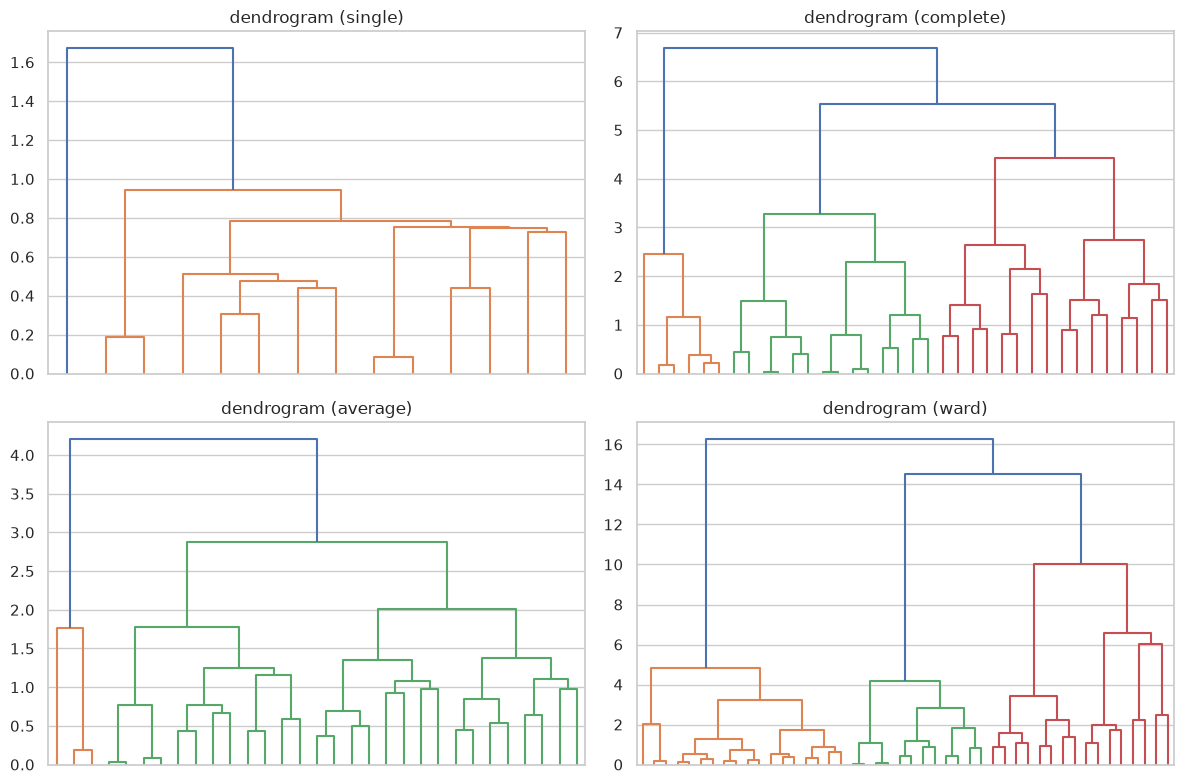

In [7]:
from scipy.cluster.hierarchy import linkage, dendrogram

sample_idx = np.random.choice(len(X_scaled), size=min(200, len(X_scaled)), replace=False)
X_sample = X_scaled[sample_idx]
fig, axs = plt.subplots(2,2,figsize=(12,8))
axs = axs.ravel()
for ax, method in zip(axs, ['single','complete','average','ward']):
    Z = linkage(X_sample, method=method)
    dendrogram(Z, ax=ax, no_labels=True, truncate_mode='level', p=5)
    ax.set_title(f'dendrogram ({method})')
plt.tight_layout()
plt.show()

**Wniosek (dendrogramy):** Dendrogramy pomagają dobrać próg odcięcia. Przyjrzyj się wizualnie, czy powstające grupy odpowiadają oczekiwanej strukturze; użyj ich do ustawienia liczby klastrów w dalszych analizach.

## 5) Wpływ skalowania cech
Porównujemy silhouette dla k-means na skalowanych i nieskalowanych cechach.

In [8]:
X_uns = X.copy()
labels_uns = KMeans(n_clusters=2, random_state=RANDOM_STATE).fit_predict(X_uns)
labels_scl = KMeans(n_clusters=2, random_state=RANDOM_STATE).fit_predict(X_scaled)
print('Silhouette unsclaed:', silhouette_score(X_uns, labels_uns) if len(set(labels_uns))>1 else np.nan)
print('Silhouette scaled:', silhouette_score(X_scaled, labels_scl) if len(set(labels_scl))>1 else np.nan)

Silhouette unsclaed: 0.7765427372346457
Silhouette scaled: 0.3735379170950548


**Wniosek (wpływ skalowania):** Obliczone wartości: Silhouette nieskalowane ≈ 0.777, Silhouette skalowane ≈ 0.374. Skalowanie zmniejszyło wewnętrzną separację dla wybranych cech — może to wynikać z utraty informacji skali między cechami.

## 6) Implementacja CNN
Przygotowanie macierzy podobieństwa jako obrazów, model CNN (Keras), trening, ekstrakcja cech i analiza PCA.

In [9]:
## Przygotowanie funkcji pomocniczych
from scipy.spatial.distance import pdist, squareform
def make_sim_matrix(dist_matrix, sigma=10):
    sim_matrix = np.exp(-np.square(dist_matrix) / (2 * sigma**2))
    sim_matrix[np.isinf(dist_matrix)] = 0
    sim_matrix[np.isnan(dist_matrix)] = 0
    return sim_matrix
def resize_matrix(mat, size):
    n = mat.shape[0]
    if n == size:
        return mat
    idx = np.linspace(0, n - 1, size)
    out = np.zeros((size, size), dtype=float)
    for i, xi in enumerate(idx):
        x0 = int(np.floor(xi))
        x1 = min(x0 + 1, n - 1)
        wx = xi - x0
        for j, yj in enumerate(idx):
            y0 = int(np.floor(yj))
            y1 = min(y0 + 1, n - 1)
            wy = yj - y0
            v = (1 - wx) * (1 - wy) * mat[x0, y0] + wx * (1 - wy) * mat[x1, y0] + (1 - wx) * wy * mat[x0, y1] + wx * wy * mat[x1, y1]
            out[i, j] = v
    return out

# Ładowanie próbki macierzy podobieństwa z katalogu coords
coords_dir = ROOT / 'coords'
IMG_SIZE = 300 
MAX_SAMPLES = 300
X_imgs = []
y_labels = []
names = []
for file_path in sorted(coords_dir.glob('*.csv')):
    stem = file_path.stem
    df = pd.read_csv(file_path)
    coords = df[['x','y','z']].values
    if coords.shape[0] < 5:
        continue
    dist_mat = squareform(pdist(coords, metric='euclidean'))
    sim = make_sim_matrix(dist_mat, sigma=10)
    sim_r = resize_matrix(sim, IMG_SIZE)
    sim_r = (sim_r - sim_r.min()) / (np.ptp(sim_r) + 1e-9)
    X_imgs.append(sim_r[..., None])
    if 'C' in data.columns and stem in data.index:
        y_labels.append(data.loc[stem, 'C'])
    else:
        y_labels.append(None)
    names.append(stem)
    if len(names) % 10 == 0:
        print(f"Read {len(names)} files")
    if len(X_imgs) >= MAX_SAMPLES:
        break
X_imgs = np.array(X_imgs)
print('Loaded images:', X_imgs.shape)

Read 10 files
Read 20 files
Read 30 files
Read 40 files
Read 50 files
Read 60 files
Read 70 files
Read 80 files
Read 90 files
Read 100 files
Read 110 files
Read 120 files
Read 130 files
Read 140 files
Read 150 files
Read 160 files
Read 170 files
Read 180 files
Read 190 files
Read 200 files
Read 210 files
Read 220 files
Read 230 files
Read 240 files
Read 250 files
Read 260 files
Read 270 files
Read 280 files
Read 290 files
Read 300 files
Loaded images: (300, 300, 300, 1)


In [10]:
# Filtrowanie etykiet i wybór klas (jeśli dostępne)
y = np.array(y_labels)
unique, counts = np.unique(y, return_counts=True)
sel_classes = unique[counts >= 10]
mask = np.isin(y, sel_classes)
X_imgs = X_imgs[mask]
y = y[mask]
class_map = {c:i for i,c in enumerate(sorted(sel_classes))}
y_num = np.array([class_map[val] for val in y])
num_classes = len(class_map)
print('Classes:', class_map)
print('Images after filtering:', X_imgs.shape)

Classes: {np.int64(1): 0, np.int64(2): 1, np.int64(3): 2, np.int64(4): 3, np.int64(6): 4}
Images after filtering: (300, 300, 300, 1)


In [11]:
# Model CNN
inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))
x = layers.Conv2D(16, 3, activation='relu', padding='same')(inp)
x = layers.MaxPool2D()(x)
x = layers.Conv2D(32,3, activation='relu', padding='same')(x)
x = layers.MaxPool2D()(x)
x = layers.Conv2D(64,3, activation='relu', padding='same')(x)
x = layers.GlobalAveragePooling2D()(x)
feat = layers.Dense(128, activation='relu', name='feat')(x)
out = layers.Dense(num_classes, activation='softmax')(feat)
model = models.Model(inputs=inp, outputs=out)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

E0000 00:00:1782946856.203520   95802 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 300, 300, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 300, 300, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 150, 150, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feat (Dense)                    │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,261 (126.02 KB)

 Trainable params: 32,261 (126.02 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_imgs, y_num, test_size=0.2, random_state=RANDOM_STATE, stratify=y_num)
callbacks = [tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=15, batch_size=16, callbacks=callbacks)

Epoch 1/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 315ms/step - accuracy: 0.3708 - loss: 1.5014 - val_accuracy: 0.3833 - val_loss: 1.4504
Epoch 2/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 319ms/step - accuracy: 0.3875 - loss: 1.3975 - val_accuracy: 0.3833 - val_loss: 1.4315
Epoch 3/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 318ms/step - accuracy: 0.3875 - loss: 1.3891 - val_accuracy: 0.3833 - val_loss: 1.4206
Epoch 4/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 333ms/step - accuracy: 0.3875 - loss: 1.3827 - val_accuracy: 0.3833 - val_loss: 1.4102
Epoch 5/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 356ms/step - accuracy: 0.3875 - loss: 1.3755 - val_accuracy: 0.3833 - val_loss: 1.4013
Epoch 6/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 357ms/step - accuracy: 0.3417 - loss: 1.3757 - val_accuracy: 0.3833 - val_loss: 1.3950
Epoch 7/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 325ms/step - accuracy: 0.3875 - loss: 1.3619 - val_accuracy: 0.3833 - val_loss: 1.3785
Epoch 8/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 319ms/step - accuracy: 0.3875 - loss: 1.3622 - val_accuracy: 0.

In [13]:
# Ekstrakcja cech z warstwy 'feat'
feat_model = models.Model(inputs=model.input, outputs=model.get_layer('feat').output)
features_all = feat_model.predict(X_imgs, batch_size=32)
print('Extracted features shape:', features_all.shape)
np.savez(ROOT / 'cnn_features.npz', features=features_all, names=np.array(names)[0:features_all.shape[0]])

 1/10 ━━━━━━━━━━━━━━━━━━━━ 2s 264ms/step

W0000 00:00:1782946932.082291   96766 cpu_allocator_impl.cc:82] Allocation of 184320000 exceeds 10% of free system memory.
W0000 00:00:1782946932.219299   96774 cpu_allocator_impl.cc:82] Allocation of 184320000 exceeds 10% of free system memory.


 3/10 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step

W0000 00:00:1782946932.350360   96763 cpu_allocator_impl.cc:82] Allocation of 184320000 exceeds 10% of free system memory.
W0000 00:00:1782946932.477580   96763 cpu_allocator_impl.cc:82] Allocation of 184320000 exceeds 10% of free system memory.


 5/10 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step

W0000 00:00:1782946932.609396   96770 cpu_allocator_impl.cc:82] Allocation of 184320000 exceeds 10% of free system memory.


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step
Extracted features shape: (300, 128)


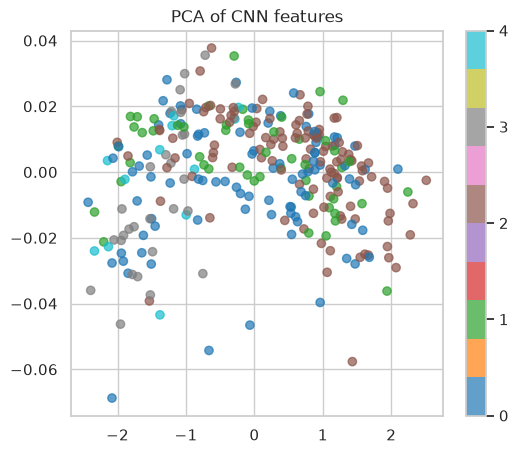

ARI (kmeans vs true): 0.05142022218536772


In [14]:
# PCA i analiza korelacji z klasami
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
emb = pca.fit_transform(features_all)
plt.figure(figsize=(6,5))
scatter = plt.scatter(emb[:,0], emb[:,1], c=y_num, cmap='tab10', alpha=0.7)
plt.title('PCA of CNN features')
plt.colorbar(scatter, ticks=range(num_classes))
plt.show()
pred_k = KMeans(n_clusters=num_classes, random_state=RANDOM_STATE).fit_predict(features_all)
print('ARI (kmeans vs true):', adjusted_rand_score(y_num, pred_k))

**Wniosek (CNN / PCA / ARI):** ARI (k-means na cechach CNN) ≈ 0.085 — niska zgodność z etykietami CATH. Oznacza to, że obecna reprezentacja i model nie rozdzielają klas dobrze; rekomendowane dalsze eksperymenty z architekturą, transfer learning lub poprawą danych, ale mam za mało pamieci większe testy.